In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import json

from sklearn import model_selection, preprocessing, linear_model, metrics
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn import ensemble
from lightgbm import LGBMClassifier
from sklearn.metrics import roc_auc_score, roc_curve
from xgboost import XGBClassifier
from wordcloud import WordCloud, STOPWORDS, ImageColorGenerator
from termcolor import colored
from sklearn.metrics import plot_confusion_matrix
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords
from textblob import Word
nltk.download('wordnet')

from nltk.tokenize import word_tokenize
from tqdm import tqdm
import re

from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing import sequence
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.layers import Dense,Dropout,Embedding,LSTM
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.losses import categorical_crossentropy
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import Sequential


from warnings import filterwarnings
filterwarnings('ignore')

from sklearn import set_config
set_config(print_changed_only = False)

print(colored("\nLIBRARIES WERE SUCCESFULLY IMPORTED...", "green"))

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\chand\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\chand\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!



LIBRARIES WERE SUCCESFULLY IMPORTED...


In [2]:
file = open("Sarcasm_Headlines_Dataset.json")
json_data = [json.loads(line) for line in file]
json_data[0:5]

[{'article_link': 'https://www.huffingtonpost.com/entry/versace-black-code_us_5861fbefe4b0de3a08f600d5',
  'headline': "former versace store clerk sues over secret 'black code' for minority shoppers",
  'is_sarcastic': 0},
 {'article_link': 'https://www.huffingtonpost.com/entry/roseanne-revival-review_us_5ab3a497e4b054d118e04365',
  'headline': "the 'roseanne' revival catches up to our thorny political mood, for better and worse",
  'is_sarcastic': 0},
 {'article_link': 'https://local.theonion.com/mom-starting-to-fear-son-s-web-series-closest-thing-she-1819576697',
  'headline': "mom starting to fear son's web series closest thing she will have to grandchild",
  'is_sarcastic': 1},
 {'article_link': 'https://politics.theonion.com/boehner-just-wants-wife-to-listen-not-come-up-with-alt-1819574302',
  'headline': 'boehner just wants wife to listen, not come up with alternative debt-reduction ideas',
  'is_sarcastic': 1},
 {'article_link': 'https://www.huffingtonpost.com/entry/jk-rowling-w

In [3]:
texts = []
labels = []
urls = []

for item in json_data:
    texts.append(item["headline"])
    labels.append(item["is_sarcastic"])
    urls.append(item["article_link"])

In [4]:
texts[0:10]

["former versace store clerk sues over secret 'black code' for minority shoppers",
 "the 'roseanne' revival catches up to our thorny political mood, for better and worse",
 "mom starting to fear son's web series closest thing she will have to grandchild",
 'boehner just wants wife to listen, not come up with alternative debt-reduction ideas',
 'j.k. rowling wishes snape happy birthday in the most magical way',
 "advancing the world's women",
 'the fascinating case for eating lab-grown meat',
 'this ceo will send your kids to school, if you work for his company',
 'top snake handler leaves sinking huckabee campaign',
 "friday's morning email: inside trump's presser for the ages"]

In [5]:
labels[0:10]

[0, 0, 1, 1, 0, 0, 0, 0, 1, 0]

In [6]:
urls[0:5] 

['https://www.huffingtonpost.com/entry/versace-black-code_us_5861fbefe4b0de3a08f600d5',
 'https://www.huffingtonpost.com/entry/roseanne-revival-review_us_5ab3a497e4b054d118e04365',
 'https://local.theonion.com/mom-starting-to-fear-son-s-web-series-closest-thing-she-1819576697',
 'https://politics.theonion.com/boehner-just-wants-wife-to-listen-not-come-up-with-alt-1819574302',
 'https://www.huffingtonpost.com/entry/jk-rowling-wishes-snape-happy-birthday_us_569117c4e4b0cad15e64fdcb']

In [7]:
len(texts), len(labels), len(urls)

(26709, 26709, 26709)

In [8]:
df = pd.DataFrame()
df["text"] = texts
df["label"] = labels
df.head(n = 10).style.background_gradient(cmap = "autumn")

,text,label
0,former versace store clerk sues over secret 'black code' for minority shoppers,0
1,"the 'roseanne' revival catches up to our thorny political mood, for better and worse",0
2,mom starting to fear son's web series closest thing she will have to grandchild,1
3,"boehner just wants wife to listen, not come up with alternative debt-reduction ideas",1
4,j.k. rowling wishes snape happy birthday in the most magical way,0
5,advancing the world's women,0
6,the fascinating case for eating lab-grown meat,0
7,"this ceo will send your kids to school, if you work for his company",0
8,top snake handler leaves sinking huckabee campaign,1
9,friday's morning email: inside trump's presser for the ages,0


In [9]:


df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26709 entries, 0 to 26708
Data columns (total 2 columns):
text     26709 non-null object
label    26709 non-null int64
dtypes: int64(1), object(1)
memory usage: 417.5+ KB


In [10]:
df.duplicated().sum()

107

In [11]:
df.drop_duplicates(inplace = True)

In [12]:
df.groupby("label").count().style.background_gradient(cmap = "autumn")

,text
label,
0,14951
1,11651


<function matplotlib.pyplot.show(close=None, block=None)>

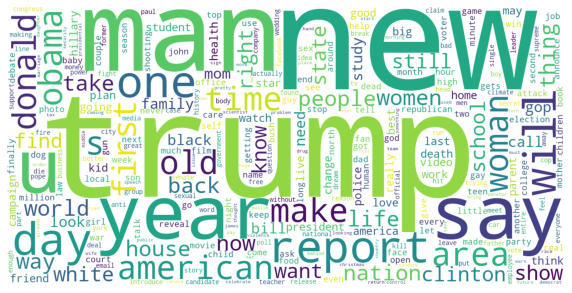

In [13]:
text = " ".join(i for i in df.text)

wc = WordCloud(background_color = "white",
               width = 1200,
               height = 600,
               contour_width = 0,
               contour_color = "red",
               max_words = 300,
               scale = 1,
               collocations = False,
               repeat = True,
               min_font_size = 1)

wc.generate(text)

plt.figure(figsize = [10, 10])
plt.imshow(wc)
plt.axis("off")
plt.show

In [14]:
df["text"] = df["text"].apply(lambda x: " ".join(x.lower() for x in x.split()))

print(colored("\nCONVERTED SUCCESFULLY...", "green"))


CONVERTED SUCCESFULLY...


In [15]:
df["text"] = df["text"].str.replace('[^\w\s]','')

print(colored("\nDELETED PUNCTUATION MARKS SUCCESFULLY...", "green"))


DELETED PUNCTUATION MARKS SUCCESFULLY...


In [16]:
df["text"] = df["text"].str.replace('\d','')

print(colored("\n NUMBERS DELETED SUCCESFULLY...", "green"))


 NUMBERS DELETED SUCCESFULLY...


In [17]:
sw = stopwords.words("english")
df["text"] = df["text"].apply(lambda x: " ".join(x for x in x.split() if x not in sw))

print(colored("\nSTOPWORDS DELETED SUCCESFULLY...", "green"))


STOPWORDS DELETED SUCCESFULLY...


In [18]:
df["text"] = df["text"].apply(lambda x: " ".join([Word(word).lemmatize() for word in x.split()]))

print(colored("\nDONE SUCCESFULLY...", "green"))


DONE SUCCESFULLY...


In [19]:
df.head(n = 10).style.background_gradient(cmap = "summer")

,text,label
0,former versace store clerk sue secret black code minority shopper,0
1,roseanne revival catch thorny political mood better worse,0
2,mom starting fear son web series closest thing grandchild,1
3,boehner want wife listen come alternative debtreduction idea,1
4,jk rowling wish snape happy birthday magical way,0
5,advancing world woman,0
6,fascinating case eating labgrown meat,0
7,ceo send kid school work company,0
8,top snake handler leaf sinking huckabee campaign,1
9,friday morning email inside trump presser age,0


In [20]:
x = df["text"]
y = df["label"]

train_x, test_x, train_y, test_y = model_selection.train_test_split(x, y,
                                                                    test_size = 0.20,
                                                                    shuffle = True,
                                                                    random_state = 11)


In [21]:
x

0        former versace store clerk sue secret black co...
1        roseanne revival catch thorny political mood b...
2        mom starting fear son web series closest thing...
3        boehner want wife listen come alternative debt...
4         jk rowling wish snape happy birthday magical way
                               ...                        
26704                     american politics moral freefall
26705                                    america best hike
26706                                     reparation obama
26707    israeli ban targeting boycott supporter raise ...
26708                                  gourmet gift foodie
Name: text, Length: 26602, dtype: object

In [22]:
print(train_x.shape, test_x.shape)

(21281,) (5321,)


In [23]:
tf_idf_word_vectorizer = TfidfVectorizer(analyzer = "word")
tf_idf_word_vectorizer.fit(train_x)

x_train_tf_idf_word = tf_idf_word_vectorizer.transform(train_x)
x_test_tf_idf_word = tf_idf_word_vectorizer.transform(test_x)

x_train_tf_idf_word.toarray()

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [24]:
from sklearn.metrics import *
from lib.utils import *
ac=[]
model= linear_model.LogisticRegression()
model = model.fit(x_train_tf_idf_word, train_y)
y_pred=model.predict(x_test_tf_idf_word)
ac.append(accuracy_score(y_pred,test_y,sample_weight=0.2)*100)
print(accuracy_score(y_pred,test_y,sample_weight=0.2)*100)


96.27


In [25]:
for i in range(1,10):
    if(y_pred[i]==1):
        print("Non sarcastic")
    else:
        print("Sarcastic")

Sarcastic
Sarcastic
Sarcastic
Non sarcastic
Non sarcastic
Sarcastic
Sarcastic
Sarcastic
Non sarcastic


In [26]:
unique_words = set()
len_max = 0

for sent in tqdm(train_x):
    unique_words.update(sent)
    
    if(len_max<len(sent)):
        len_max = len(sent)
        
print(len(list(unique_words)))
print(len_max)

100%|████████████████████████████████████████████████████████████████████████| 21281/21281 [00:00<00:00, 989446.78it/s]

45
226


In [27]:
tokenizer = Tokenizer(num_words=len(list(unique_words)))
tokenizer.fit_on_texts(list(train_x))

train_x = tokenizer.texts_to_sequences(train_x)
test_x = tokenizer.texts_to_sequences(test_x)

train_x = sequence.pad_sequences(train_x, maxlen=len_max)
test_x = sequence.pad_sequences(test_x, maxlen=len_max)

print(train_x.shape, test_x.shape)

(21281, 226) (5321, 226)


In [28]:
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
model = Sequential()
model.add(layers.Dense(20, input_dim=226, activation='relu'))
model.add(layers.Dense(10,  activation='tanh'))
model.add(layers.Dense(1024, activation='relu'))

model.add(layers.BatchNormalization())
model.add(layers.Dropout(0.5))
model.add(layers.Dense(1, activation='sigmoid'))
model.compile(loss='mse', 
              optimizer='adam')



In [29]:
history = model.fit(train_x, train_y, epochs = 15, validation_data = (test_x, test_y), 
                  batch_size = 16, verbose = 1)
ac.append(accuracy_score(y_pred,test_y,sample_weight=1)*100)

Epoch 1/15
1331/1331 [==============================] - 2s 1ms/step - loss: 0.2666 - val_loss: 0.2466
Epoch 2/15
1331/1331 [==============================] - 2s 1ms/step - loss: 0.2493 - val_loss: 0.2440
Epoch 3/15
1331/1331 [==============================] - 1s 1ms/step - loss: 0.2476 - val_loss: 0.2641
Epoch 4/15
1331/1331 [==============================] - 2s 1ms/step - loss: 0.2451 - val_loss: 0.2757
Epoch 5/15
1331/1331 [==============================] - 2s 1ms/step - loss: 0.2444 - val_loss: 0.2422
Epoch 6/15
1331/1331 [==============================] - 1s 1ms/step - loss: 0.2439 - val_loss: 0.2416
Epoch 7/15
1331/1331 [==============================] - 1s 1ms/step - loss: 0.2432 - val_loss: 0.2391
Epoch 8/15
1331/1331 [==============================] - 1s 1ms/step - loss: 0.2424 - val_loss: 0.2384
Epoch 9/15
1331/1331 [==============================] - 1s 1ms/step - loss: 0.2419 - val_loss: 0.2404
Epoch 10/15
1331/1331 [==============================] - 1s 1ms/step - loss: 0.241

the accuracy of Logistics Regresion is 96.27 and CNN is 93.22


,Agorithms,accuracy
0,Logistics Regresion,96.27
1,CNN,93.22


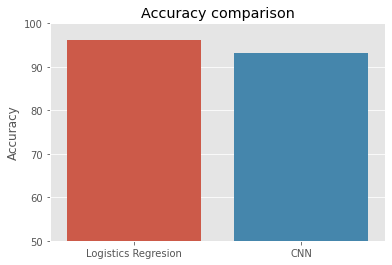

In [30]:
import numpy as np
import seaborn as sns
import matplotlib as plt

plt.style.use('ggplot')
x=['Logistics Regresion','CNN']
 
ax=sns.barplot(x,ac[:2])
ax.set_title('Accuracy comparison')
ax.set_ylabel('Accuracy')
#ax.yaxis.set_major_locator(ticker.LinearLocator())
print("the accuracy of {} is {} and {} is {}".format(x[0],ac[0],x[1],ac[1]))
ax.set_ylim(50,100)
import pandas as pd
data={'Agorithms':x,
     "accuracy":ac[:2]}
df=pd.DataFrame(data)
df.head()